# PINN

The PDE our PINN will be learning is the diffusion approximation to the Wright-Fisher model of the single-locus allele frequency spectrum $\phi(x, t)$ from population genetics. We will consider genetic drift, selection, and mutation, but not migration:

$$
\frac{\partial g}{\partial t} = \frac{1}{2N(t)}x (1 - x)\frac{\partial^2 g}{\partial x^2}- \gamma x (1 - x)\frac{\partial g}{\partial x},
$$

the first term accounts for drift, the second term selection, $N(t)$ is the relative population size, and $\gamma$ is the population-scaled selection coefficient. We are working in the rescaled density $g(x,t) = x(1-x)\phi(x,t)$, which transforms the singular boundary behaviour at $x = 0$ into a finite value (i.e. a Dirichlet boundary condition). 

The boundary conditions are

$$
g(x = 0,t) = \theta N(t),
$$

where $\theta$ is the population-scaled mutation rate, and  

$$
g(x = 1, t) = 0.
$$

The initial condition is 
$$
g(x, t = 0) = \theta N_0 \frac{1 - e^{-2\gamma(1-x)}}{1 - e^{-2\gamma}}.
$$

For this example, we'll fix $\gamma = 1$ and define $N(t) = 2t + 1$, so that $N(0) = 1$.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)  # PINNs generally need float64
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jaxtyping import Array

from popinn import (
    PINN,
    AdamConfig,
    LBFGSConfig,
    Loss,
    ResidualTerm,
    plot_training_history,
    train_model,
)

In [22]:
# Fixed values


THETA = 1.0  # population-scaled mutation rate
GAMMA = 1.0  # population-scaled selection coefficient
NFUNC = lambda t: 2.0 * t + 1  # linear population size increase

# x-coordinate boundaries
XMIN = 0.0
XMAX = 1.0

# t-coordinate maximum
TMAX = 1.0

# colocation grid lengths
NUM_PDE_PTS = 100  # points per spatial/temporal coordinate axis on PDE interior
NUM_EDGE_PTS = 256  # points used to sample the IC/boundary coordinate lines

## Residual Terms

First we'll define the per-point residual functions, one for each of our equations listed above. 

!!! Example "Important syntax note"
    Residual functions are factories that must follow the signature:
    ```python
    def fn(model):
        def r(*args, aux):
            # math
            return #scalar
        return r
    ```
    so that they can be used by the grid evaluation methods used in `ResidualTerm` and `Loss`. In this example, we have no auxiliary inputs, but we still need to include `aux` as an argument in the inner function. 

In [23]:
# PDE residual
def pde_residual(model):
    def r(x, t, aux):

        dg_dx = model.D(0)(x, t)  # d/dx
        dg_dt = model.D(1)(x, t)  # d/dt
        d2g_dx2 = model.D(0, 0)(x, t)  # d2/dx2

        diff = x * (1.0 - x) / (2.0 * NFUNC(t)) * d2g_dx2  # diffusion
        sel = GAMMA * x * (1.0 - x) * dg_dx  # selection

        # we weight the per-point residuals by their frequency x, as the gradients
        # tend to be very large at low-frequency. Wrapping x in
        # jax.lax.stop_gradient treats it like a constant, rather than a differentiable
        # quantity, so it doesn't change the PDE we are trying to solve
        return (dg_dt + sel - diff) * jax.lax.stop_gradient(x)

    return r

In [24]:
# Left BC residual
def left_bc_residual(model):
    def r(x, t, aux):
        return model(x, t) - THETA * NFUNC(t)

    return r

In [25]:
# Right BC residual
def right_bc_residual(model):
    def r(x, t, aux):
        return model(x, t)

    return r

In [ ]:
def initial_g(x, _gamma):
    return NFUNC(0) * THETA * jnp.expm1(-2.0 * _gamma * (1 - x)) / jnp.expm1(-2.0 * _gamma)


# initial condition residual
def ic_residual(model):
    def r(x, t, aux):
        return model(x, t) - initial_g(x, GAMMA)

    return r

Now that we've defined our per-point residual functions, we can turn each into a `ResidualTerm` and pass them to `Loss` to build the total loss. By default, each term has a weight of 1. We can define custom weights for each term using a mapping or a subclass of `AbstractWeights` like `FixedWeights`, but for this example we'll stick with the default.

In [27]:
total_loss = Loss(
    [
        ResidualTerm(name="pde", residual_fn=pde_residual),
        ResidualTerm(name="left_bc", residual_fn=left_bc_residual),
        ResidualTerm(name="right_bc", residual_fn=right_bc_residual),
        ResidualTerm(name="ic", residual_fn=ic_residual),
    ]
)

## Training Data

Next, we set up a data container with `equinox.Module`. Each field of the container should be called `<name>_coords`, where `<name>` corresponds to the name of a `ResidualTerm` defined above. The only field that can be something other than `<name>_coords` is `aux`, which is a tuple containing all the auxiliary inputs for our model. Since we have no auxiliary inputs, we must pass an empty tuple to `aux`.

!!! Example "Important syntax note"
    *Reiterating because this is important*: the data containers must follow the format
    ```python
    class TrainingData(eqx.Module):
        <name1>_coords: tuple[Array]
        <name2>_coords: tuple[Array]
        # ...
        aux: tuple
    ```
    where each `<name#>` corresponds to the `name` of each defined `ResidualTerm`. Ex: `pde_coords` for the `ResidualTerm` named `'pde'` above.

!!! FAQ "Why `equinox.Module` and not a dictionary?"
    The short answer is that it's what Loss expects: it reads the data like data.pde_coords, not data['pde_coords'], so just passing in a dictionary will fail. The longer answer is that an equinox.Module gives us a few perks a dictionary wouldn't. Its fields are immutable, so we can't accidentally modify the data in place; instead, Equinox defines a clean interface for updating pytrees (see [JAX's documentation](https://docs.jax.dev/en/latest/pytrees.html) to learn more about pytrees) with `equinox.tree_at`, which matters once we want to, say, resample the collocation data each training step. Finally, it keeps everything consistent across popinn: anything that passes through jit/grad is an `equinox.Module`.

In [28]:
class TrainingData(eqx.Module):
    pde_coords: tuple[Array]
    ic_coords: tuple[Array]
    left_bc_coords: tuple[Array]
    right_bc_coords: tuple[Array]
    aux: tuple


X_pde = jnp.linspace(XMIN, XMAX, NUM_PDE_PTS)
T_pde = jnp.linspace(0, TMAX, NUM_PDE_PTS)

X_ic = jnp.linspace(XMIN, XMAX, NUM_EDGE_PTS)
T_ic = jnp.zeros(1)

T_bc = jnp.linspace(0, TMAX, NUM_EDGE_PTS)
X_lbc = XMIN * jnp.ones(1)
X_rbc = XMAX * jnp.ones(1)


data = TrainingData(
    pde_coords=(X_pde, T_pde),
    ic_coords=(X_ic, T_ic),
    left_bc_coords=(X_lbc, T_bc),
    right_bc_coords=(X_rbc, T_bc),
    aux=(),
)

!!! FAQ "Tuples and coordinate axis mapping"
    By passing in the coordinates as a tuple of arrays, rather than a stacked `jax.numpy` array, we can have coordinates arrays with different lengths. Notice how, for example, `T_ic` is an array with shape `(1,)` while `X_ic` has a shape `(NUM_EDGE_PTS,)`. 

    Under the hood, `ResidualTerm` will evaluate its corresponding function over an outer-product of each coordinate axis using `jax.vmap`. This means we never need to construct a meshgrid of data ourselves and a large array with shape `(NUM_PDE_PTS, NUM_PDE_PTS)` is only materialized in memory when the loss is computed. This isn't a concern in a this small example, but can be in problems with higher numbers of dimensions or with additional auxiliary inputs.

## Initialize Model and Train

We'll first train with 500 Adam steps, then 1k of L-BFGS:

In [34]:
key = jr.PRNGKey(3)
model = PINN(key, num_coords=2)  # our coordinates are x & t

model, history = train_model(
    model,
    data,
    total_loss,
    [AdamConfig(log_every=100, num_epochs=1000, lr=1e-3), LBFGSConfig(log_every=100, num_epochs=1000)],
)

[Adam] Starting (1000 epochs)
[Adam] Epoch      1 | total: 2.58e+00 | ic: 8.49e-02  left_bc: 1.98e+00  pde: 1.71e-04  right_bc: 5.16e-01
[Adam] Epoch    100 | total: 1.46e-01 | ic: 7.77e-02  left_bc: 3.43e-02  pde: 1.02e-02  right_bc: 2.37e-02
[Adam] Epoch    200 | total: 6.15e-02 | ic: 1.63e-02  left_bc: 2.21e-03  pde: 2.25e-02  right_bc: 2.05e-02
[Adam] Epoch    300 | total: 5.07e-02 | ic: 1.04e-02  left_bc: 8.21e-04  pde: 2.21e-02  right_bc: 1.74e-02
[Adam] Epoch    400 | total: 2.20e-02 | ic: 2.62e-03  left_bc: 2.13e-04  pde: 1.14e-02  right_bc: 7.82e-03
[Adam] Epoch    500 | total: 9.19e-03 | ic: 5.44e-04  left_bc: 9.94e-05  pde: 5.25e-03  right_bc: 3.30e-03
[Adam] Epoch    600 | total: 6.16e-03 | ic: 3.26e-04  left_bc: 5.30e-05  pde: 3.73e-03  right_bc: 2.05e-03
[Adam] Epoch    700 | total: 5.33e-03 | ic: 2.32e-04  left_bc: 6.49e-04  pde: 2.96e-03  right_bc: 1.49e-03
[Adam] Epoch    800 | total: 3.89e-03 | ic: 1.83e-04  left_bc: 2.10e-05  pde: 2.33e-03  right_bc: 1.35e-03
[Adam] 

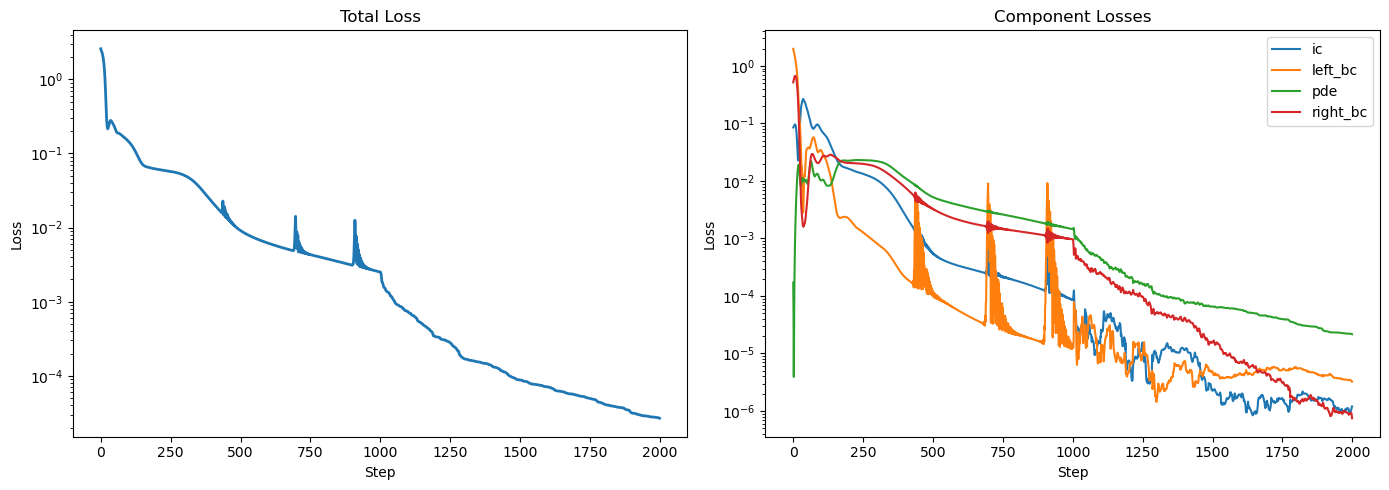

In [39]:
plot_training_history(history)

We'll check our trained solution at $t = 1$ against a numerical solver, specifically the solver included in the [`dadi`](https://github.com/RyanGutenkunst/dadi) package. `dadi` works in the untransformed frequency $\phi(x,t)$, so we'll need to multiply it by $x(1-x)$ to convert it to $g(x,t)$

In [36]:
import dadi


def calc_dadi(tf=1.0, pts=300):
    xx = dadi.Numerics.default_grid(pts=pts)
    phi0 = dadi.PhiManip.phi_1D(xx, gamma=GAMMA)
    phif = dadi.Integration.one_pop(phi0, xx, tf, lambda t: NFUNC(t), gamma=GAMMA)
    return xx, phif, phi0

In [37]:
x_dadi, phi_dadi, phi0_dadi = calc_dadi()
g_test = jax.vmap(model, in_axes=(0, None))(X_pde, 1.0)

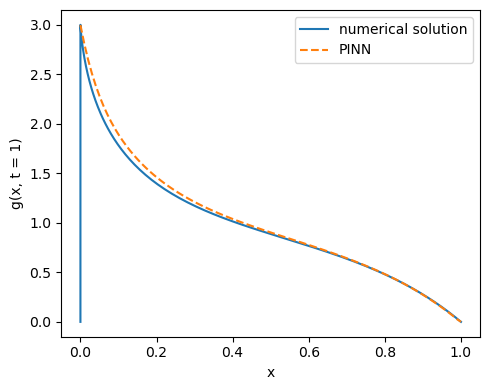

In [38]:
plt.figure(figsize=(5, 4))
plt.plot(x_dadi, phi_dadi * x_dadi * (1.0 - x_dadi), label="numerical solution")  # convert phi to g
plt.plot(X_pde, g_test, label="PINN", ls="--")
plt.legend()
plt.xlabel("x")
plt.ylabel("g(x, t = 1)")
plt.tight_layout()

The PINN tracks the solution well. We can improve the solution recovery at low frequency by traning for longer or by including more collocation points in that region and re-trainig. We could also try retraining with a larger weight for the PDE loss term or increasing the size of our network. Like most neural networks, PINNs typically require some fine-tuning.

## Next Steps

Review the core principles section, then move on to the P$^2$INN example to see auxiliary inputs in action.